# NN 6


# Imports

In [17]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from ultralytics import YOLO
from PIL import Image
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Task 1 — Object Detection with a Pretrained YOLO Model (2 pts)

Use a pretrained YOLO model from Ultralytics.

Suggested models:

* `yolo11n.pt`
* `yolo26n.pt`

## Requirements


1. Install and import Ultralytics.
2. Load a pretrained YOLO detection model.
3. Run inference on at least **3 images**.
4. Visualize predictions on the images.
5. For one selected image, print or display:
   * predicted boxes,
   * class IDs,
   * class names,
   * confidence scores,
   * tensor shapes.
6. For one image, create a small table with columns:

| Box index | Class name | Confidence | x1  | y1  | x2  | y2  | Width | Height |
|----------:|------------|-----------:|----:|----:|----:|----:|------:|-------:|
| ...       | ...        | ...        | ... | ... | ... | ... | ...   | ...    |


7. Run the same image with **two different confidence thresholds**, for example:

```python
conf_thresholds = [0.25, 0.50]
```

Create a short table:

| Confidence threshold | Number of detections | Observation |
|---------------------:|---------------------:|-------------|
| 0.25                 | ...                  | ...         |
| 0.50                 | ...                  | ...         |

## Required discussion

Briefly explain:

* what the YOLO model returns for one image,
* what the confidence score means during inference,
* why changing the confidence threshold changes the number of detections,
* what object detection predicts.

In [6]:
# Image paths
image_dir = Path("images")
image_paths = list(image_dir.glob("*.jpg"))
print("Images found:", [p.name for p in image_paths])

Images found: ['bus.jpg', 'zidane.jpg', 'coco_sample.jpg']


In [7]:
model = YOLO("yolo11n.pt")

results = model.predict(
    source=[str(p) for p in image_paths],
    conf=0.25,
    verbose=False,
)
print("Number of result objects (one per input image):", len(results))


Number of result objects (one per input image): 3


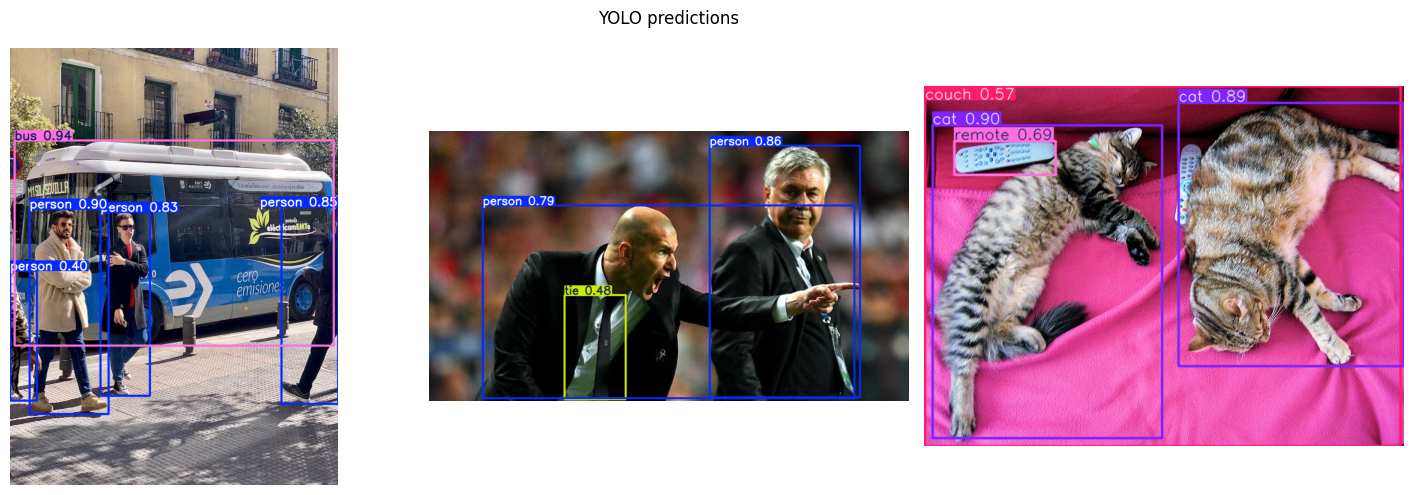

In [11]:
def show_yolo_predictions(res_list, title=None):
    fig, axes = plt.subplots(1, len(res_list), figsize=(5 * len(res_list), 5))
    if len(res_list) == 1:
        axes = [axes]
    for ax, r in zip(axes, res_list):
        ax.imshow(r.plot()[:, :, ::-1])  # BGR -> RGB
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_yolo_predictions(results, title="YOLO predictions")

In [12]:
# One image: print tensors / metadata Ultralytics exposes
sel_idx = 0
result = results[sel_idx]

boxes_xyxy = result.boxes.xyxy
cls_ids = result.boxes.cls
conf = result.boxes.conf
names = result.names  # id -> str (model's class names)

print("--- Selected image:", image_paths[sel_idx])
print("Predicted boxes (xyxy, pixel coords):\n", boxes_xyxy)
print("Class IDs:\n", cls_ids)
print("Class names (full label space):", names)
print("Predicted class names:", [names[int(i)] for i in cls_ids])
print("Confidence scores:\n", conf)
print("\nTensor shapes:")
print("  boxes_xyxy:", boxes_xyxy.shape)
print("  cls_ids:   ", cls_ids.shape)
print("  conf:      ", conf.shape)


--- Selected image: images/bus.jpg
Predicted boxes (xyxy, pixel coords):
 tensor([[ 11.8687, 228.3840, 799.2189, 735.2376],
        [ 48.5994, 397.9651, 243.2181, 904.5321],
        [670.5666, 392.6016, 810.0000, 879.6221],
        [223.1227, 405.5756, 345.2298, 859.7211],
        [  0.0000, 550.2004,  66.0046, 871.7889]], device='cuda:0')
Class IDs:
 tensor([5., 0., 0., 0., 0.], device='cuda:0')
Class names (full label space): {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tenn

In [10]:
rows = []
xy = boxes_xyxy.cpu().numpy()
cid = cls_ids.cpu().numpy().astype(int)
cf = conf.cpu().numpy()
for i in range(len(cid)):
    x1, y1, x2, y2 = xy[i]
    w, h = x2 - x1, y2 - y1
    rows.append(
        {
            "Box index": i,
            "Class name": names[cid[i]],
            "Confidence": float(cf[i]),
            "x1": float(x1),
            "y1": float(y1),
            "x2": float(x2),
            "y2": float(y2),
            "Width": float(w),
            "Height": float(h),
        }
    )

pd.DataFrame(rows)

,Box index,Class name,Confidence,x1,y1,x2,y2,Width,Height
0,0,bus,0.939376,11.868736,228.384048,799.218933,735.237610,787.350220,506.853577
1,1,person,0.901897,48.599388,397.965118,243.218124,904.532104,194.618744,506.566986
2,2,person,0.849142,670.566589,392.601562,810.000000,879.622070,139.433411,487.020508
3,3,person,0.832848,223.122696,405.575562,345.229767,859.721069,122.107071,454.145508
4,4,person,0.399345,0.000000,550.200378,66.004562,871.788940,66.004562,321.588562


In [15]:
conf_thresholds = [0.25, 0.50]
img_path = str(image_paths[sel_idx])

thresh_rows = []
pred_images = []

for c in conf_thresholds:
    r = model.predict(source=img_path, conf=c, verbose=False)[0]
    n = len(r.boxes)
    thresh_rows.append(
        {
            "Confidence threshold": c,
            "Number of detections": n,
        }
    )
    pred_images.append(r)

pd.DataFrame(thresh_rows)

,Confidence threshold,Number of detections
0,0.25,5
1,0.50,5


The number of detection is ht

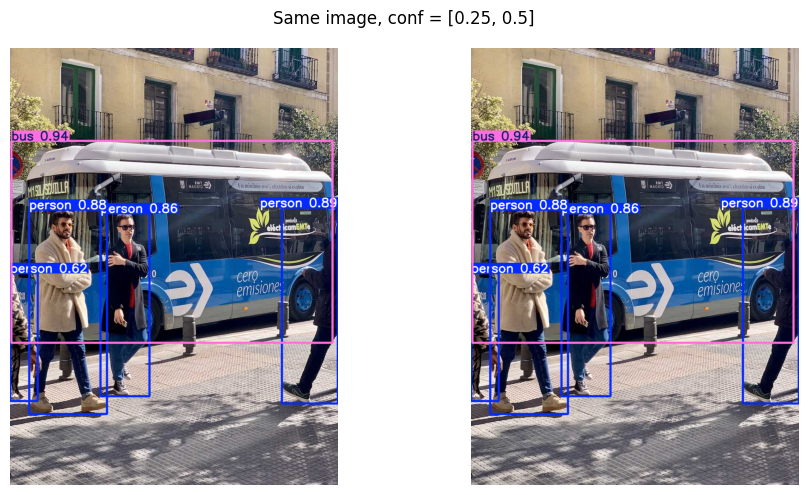

In [16]:
show_yolo_predictions(pred_images, title=f"Same image, conf = {conf_thresholds}")


### Conclusions

- **What the YOLO model returns for one image:** It returns a list of detected objects, each specified by a bounding box, a class ID with its corresponding name, and a confidence score.
- **What the confidence score means during inference:** It represents the model's estimated probability that a predicted bounding box contains an object of a specific class.
- **Why changing the confidence threshold changes the number of detections:** A lower threshold allows more uncertain predictions to be included, while a higher threshold filters out all but the most certain detections.
- **What object detection predicts:** It predicts the location and category of discrete objects within an image using axis-aligned bounding boxes.



# Task 2 — Semantic Segmentation with a Pretrained Model  (3 pts)

Use a pretrained semantic segmentation model and run inference on images. You do **not** need to train a segmentation model.

Recommended TorchVision models:

* `deeplabv3_resnet50`
* `fcn_resnet50`

You may use your own images, images from the internet, or a small dataset such as Oxford-IIIT Pet. The important part is to inspect the segmentation output and visualize predicted masks.

## Requirements


1. Load a pretrained semantic segmentation model from TorchVision.
2. Run inference on at least **3 images**.
3. Print the model output structure.
4. Print the output tensor shape.
5. Convert logits to a predicted segmentation mask using `argmax`.
6. Visualize at least **3 examples**:

```text
image | predicted segmentation mask
```


7. For one selected image, print or display:
   * input image shape,
   * output logits shape,
   * predicted mask shape,
   * unique predicted class IDs,
   * class names for the predicted class IDs, if available.
8. Create a short table:

| Image | Output shape | Predicted class IDs | Observations |
|------:|--------------|---------------------|--------------|
| 1     | ...          | ...                 | ...          |
| 2     | ...          | ...                 | ...          |
| 3     | ...          | ...                 | ...          |

## Required discussion

Briefly explain:

* what semantic segmentation predicts,
* why the output is spatial,
* why the output shape is usually similar to `B × K × H × W`,
* what `K` means,
* why `argmax` converts logits into class labels,
* how segmentation is different from object detection.

In [21]:
weights = DeepLabV3_ResNet50_Weights.DEFAULT
seg_model = deeplabv3_resnet50(weights=weights).to(device)
seg_model.eval()

preprocess = weights.transforms()
categories = weights.meta["categories"]

In [22]:
PIL_images = [Image.open(p).convert("RGB") for p in image_paths]

probe_batch = preprocess(PIL_images[0]).unsqueeze(0).to(device)
with torch.inference_mode():
    probe_out = seg_model(probe_batch)
print("Type of model output:", type(probe_out))
print("Output dict keys:", list(probe_out.keys()))
print("Example repr (truncated):", {k: tuple(v.shape) for k, v in probe_out.items()})


def run_segmentation(pil_img):
    batch = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.inference_mode():
        out = seg_model(batch)
    logits = out["out"]
    pred = logits.argmax(dim=1)  # per-pixel class ID
    return batch, logits, pred


seg_outputs = [run_segmentation(im) for im in PIL_images]
for j, (_, lg, pr) in enumerate(seg_outputs, start=1):
    print(
        f"Image {j}: logits shape BxKxHxW = {tuple(lg.shape)}, "
        f"argmax mask shape BxHxW = {tuple(pr.shape)}"
    )


Type of model output: <class 'collections.OrderedDict'>
Output dict keys: ['out', 'aux']
Example repr (truncated): {'out': (1, 21, 693, 520), 'aux': (1, 21, 693, 520)}
Image 1: logits shape BxKxHxW = (1, 21, 693, 520), argmax mask shape BxHxW = (1, 693, 520)
Image 2: logits shape BxKxHxW = (1, 21, 520, 924), argmax mask shape BxHxW = (1, 520, 924)
Image 3: logits shape BxKxHxW = (1, 21, 520, 693), argmax mask shape BxHxW = (1, 520, 693)


In [23]:
sidx = 0
batch, logits, pred = seg_outputs[sidx]

print("Input image size (W,H):", PIL_images[sidx].size)
print("Preprocessed batch shape (B,C,H',W'):", tuple(batch.shape))
print("Output logits shape (B,K,h,w):", tuple(logits.shape))
print("Predicted mask shape (B,h,w):", tuple(pred.shape))
uniq = torch.unique(pred).cpu().tolist()
print("Unique predicted class IDs:", uniq)
print("Class names for predicted IDs:", [categories[i] for i in uniq])


Input image size (W,H): (810, 1080)
Preprocessed batch shape (B,C,H',W'): (1, 3, 693, 520)
Output logits shape (B,K,h,w): (1, 21, 693, 520)
Predicted mask shape (B,h,w): (1, 693, 520)
Unique predicted class IDs: [0, 6, 15]
Class names for predicted IDs: ['__background__', 'bus', 'person']


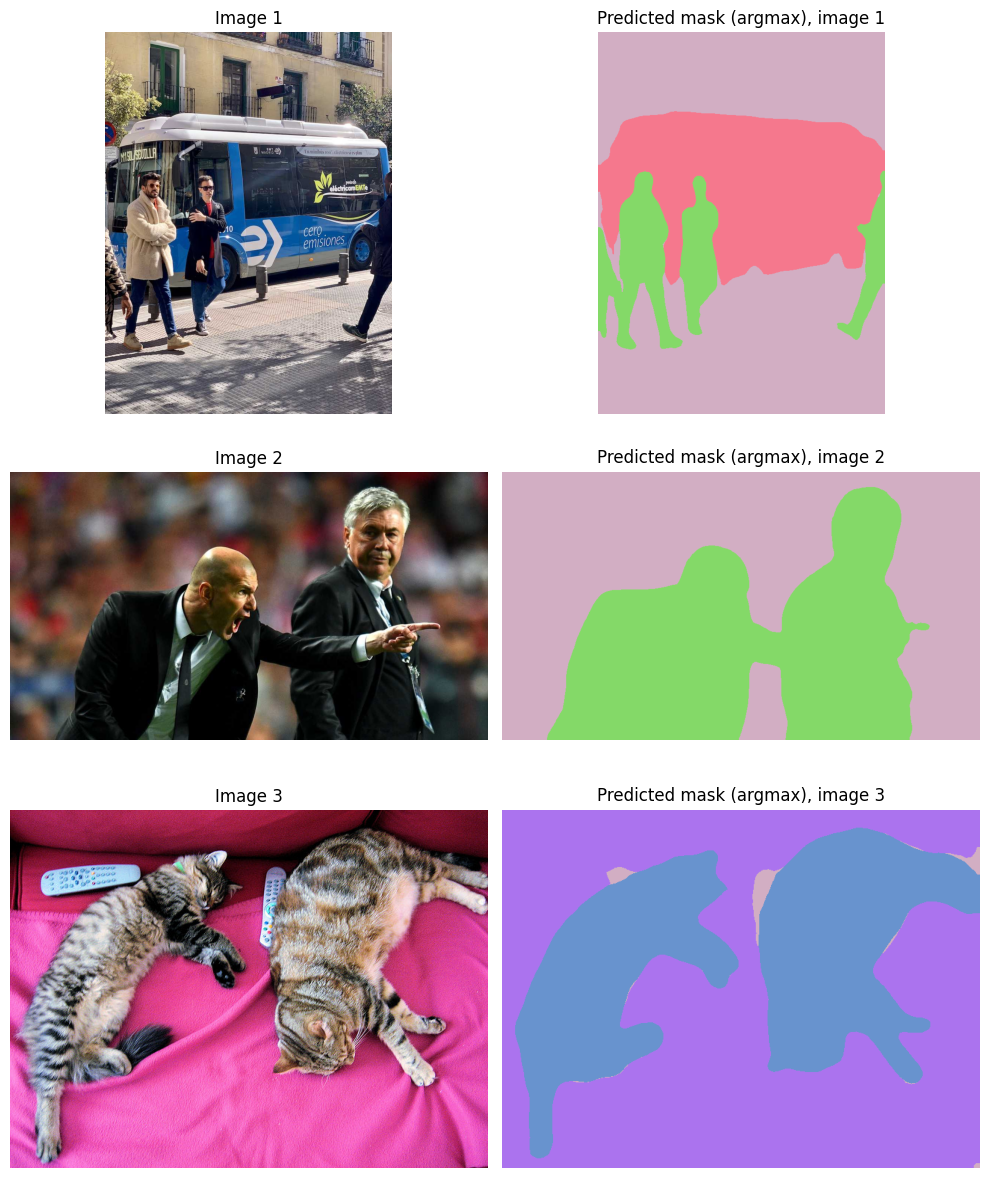

In [24]:
def label_to_color_mask(mask_2d, num_classes=len(categories)):
    # Simple deterministic coloring for visualization (not official VOC palette)
    mask = mask_2d.cpu().numpy()
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.float32)
    rng = np.random.default_rng(num_classes)
    palette = rng.uniform(0.2, 1.0, size=(num_classes, 3))
    for cls_id in np.unique(mask):
        rgb[mask == cls_id] = palette[int(cls_id) % num_classes]
    return np.clip(rgb, 0, 1)


fig, axes = plt.subplots(len(PIL_images), 2, figsize=(10, 4 * len(PIL_images)))
if len(PIL_images) == 1:
    axes = np.array([axes])

for i, (pil_im, (_, _, pred_m)) in enumerate(zip(PIL_images, seg_outputs)):
    axes[i, 0].imshow(pil_im)
    axes[i, 0].set_title(f"Image {i+1}")
    axes[i, 0].axis("off")

    colored = label_to_color_mask(pred_m[0])
    axes[i, 1].imshow(colored)
    axes[i, 1].set_title(f"Predicted mask (argmax), image {i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()


In [26]:
summary_rows = []
for i, (_, logits_i, pred_i) in enumerate(seg_outputs, start=1):
    u = torch.unique(pred_i).cpu().tolist()
    summary_rows.append(
        {
            "Image": i,
            "Output shape (logits B,K,H,W)": str(tuple(logits_i.shape)),
            "Predicted class IDs": ", ".join(str(x) for x in u),
        }
    )

pd.DataFrame(summary_rows)


,Image,"Output shape (logits B,K,H,W)",Predicted class IDs
0,1,"(1, 21, 693, 520)","0, 6, 15"
1,2,"(1, 21, 520, 924)","0, 15"
2,3,"(1, 21, 520, 693)","0, 8, 18"



### Task 2 — Conclusions

- **What semantic segmentation predicts:** Semantic segmentation predicts a dense, pixel-wise classification map where every pixel in the image is assigned a specific class label.
- **Why the output is spatial:** The output is spatial because the model must preserve the 2D layout of the input image to correctly assign labels to their corresponding physical locations.
- **Why the output shape is usually similar to `B × K × H × W`:** The shape represents batch size, number of classes (as channels), and spatial dimensions, allowing the model to provide a score for every class at every pixel location.
- **What `K` means:** `K` represents the number of semantic categories (including background) that the model is trained to recognize and distinguish.
- **Why `argmax` converts logits into class labels:** `argmax` identifies the index of the highest logit at each pixel, which corresponds to the model's most likely class prediction for that location.
- **How segmentation is different from object detection:** Segmentation provides dense, pixel-perfect boundaries for all regions, whereas object detection outputs a sparse set of axis-aligned bounding boxes for individual objects.


## Final Comparison

1. **What does object detection predict?** A set of objects, each with a bounding box, class, and confidence (sparse over the image).
2. **What does semantic segmentation predict?** A dense map: one predicted class per pixel (or per spatial cell in the logits grid).
3. **Which task uses bounding boxes?** Object detection.
4. **Which task uses pixel-wise labels?** Semantic segmentation.
5. **Which task was easier to visualize and why?** **Object detection** is often quicker to read: overlaid colored boxes and labels map directly to familiar “objects.” Segmentation masks require a color legend or overlay and can look noisy at class boundaries, but they show fine spatial extent of categories.
